In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.tree import (DecisionTreeRegressor, export_text)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction import DictVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

pd.set_option("display.max_columns", None)

Dataset, remember to decompress zip file in data folder

In [123]:
fps_csv = "../data/fps_videogames.csv"
fps_df = pd.read_csv(fps_csv, na_values=["?"])

EDA

In [124]:
fps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425833 entries, 0 to 425832
Data columns (total 46 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         425833 non-null  int64  
 1   CpuName                    425833 non-null  object 
 2   CpuNumberOfCores           425833 non-null  int64  
 3   CpuNumberOfThreads         425833 non-null  int64  
 4   CpuBaseClock               425833 non-null  int64  
 5   CpuCacheL1                 425833 non-null  int64  
 6   CpuCacheL2                 425833 non-null  int64  
 7   CpuCacheL3                 420778 non-null  float64
 8   CpuDieSize                 223299 non-null  float64
 9   CpuFrequency               425833 non-null  int64  
 10  CpuMultiplier              425833 non-null  float64
 11  CpuMultiplierUnlocked      425833 non-null  int64  
 12  CpuProcessSize             425833 non-null  int64  
 13  CpuTDP                     42

In [125]:
fps_df.columns

Index(['id', 'CpuName', 'CpuNumberOfCores', 'CpuNumberOfThreads',
       'CpuBaseClock', 'CpuCacheL1', 'CpuCacheL2', 'CpuCacheL3', 'CpuDieSize',
       'CpuFrequency', 'CpuMultiplier', 'CpuMultiplierUnlocked',
       'CpuProcessSize', 'CpuTDP', 'CpuNumberOfTransistors', 'CpuTurboClock',
       'GpuName', 'GpuArchitecture', 'GpuBandwidth', 'GpuBaseClock',
       'GpuBoostClock', ''GpuBus', 'GpuNumberOfComputeUnits', 'GpuDieSize',
       'GpuDirectX', 'GpuNumberOfExecutionUnits', 'GpuFP32Performance',
       'GpuMemoryBus', 'GpuMemorySize', 'GpuMemoryType', 'GpuOpenCL',
       'GpuOpenGL', 'GpuPixelRate', 'GpuProcessSize', 'GpuNumberOfROPs',
       'GpuShaderModel', 'GpuNumberOfShadingUnits', 'GpuNumberOfTMUs',
       'GpuTextureRate', 'GpuNumberOfTransistors', 'GpuVulkan', 'GameName',
       'GameResolution', 'GameSetting', 'Dataset', 'FPS'],
      dtype='object')

In [126]:
fps_df.head()

,id,CpuName,CpuNumberOfCores,CpuNumberOfThreads,CpuBaseClock,CpuCacheL1,CpuCacheL2,CpuCacheL3,CpuDieSize,CpuFrequency,CpuMultiplier,CpuMultiplierUnlocked,CpuProcessSize,CpuTDP,CpuNumberOfTransistors,CpuTurboClock,GpuName,GpuArchitecture,GpuBandwidth,GpuBaseClock,GpuBoostClock,'GpuBus,GpuNumberOfComputeUnits,GpuDieSize,GpuDirectX,GpuNumberOfExecutionUnits,GpuFP32Performance,GpuMemoryBus,GpuMemorySize,GpuMemoryType,GpuOpenCL,GpuOpenGL,GpuPixelRate,GpuProcessSize,GpuNumberOfROPs,GpuShaderModel,GpuNumberOfShadingUnits,GpuNumberOfTMUs,GpuTextureRate,GpuNumberOfTransistors,GpuVulkan,GameName,GameResolution,GameSetting,Dataset,FPS
0,1,Intel Core i7-920,4,8,133,256,1024,8.0,0.000263,2666,20.0,0,45,130,731.0,2933,AMD Radeon RX 480,GCN 4.0,256000.0,1120,1266,PCIe 3.0 x16,36.0,0.000232,12,NaN,5834000.0,256.0,8000.0,GDDR5,2.0,4.6,40510,14,32,6.4,2304.0,144,182300,5700.0,1.2.131,counterStrikeGlobalOffensive,1080,low,userbenchmark,70.0
1,2,Intel Core i7-920,4,8,133,256,1024,8.0,0.000263,2666,20.0,0,45,130,731.0,2933,AMD Radeon RX 480,GCN 4.0,256000.0,1120,1266,PCIe 3.0 x16,36.0,0.000232,12,NaN,5834000.0,256.0,8000.0,GDDR5,2.0,4.6,40510,14,32,6.4,2304.0,144,182300,5700.0,1.2.131,counterStrikeGlobalOffensive,1080,low,userbenchmark,230.0
2,3,Intel Core i5-4690,4,4,100,256,1024,6.0,0.000177,3400,34.0,0,22,84,1400.0,3800,NVIDIA GeForce GTX 1080 11Gbps,Pascal,352300.0,1607,1733,PCIe 3.0 x16,NaN,0.000314,12,NaN,8873000.0,256.0,8000.0,GDDR5X,1.2,4.6,110900,16,64,6.4,2560.0,160,277300,7200.0,1.2.131,counterStrikeGlobalOffensive,1080,low,userbenchmark,250.0
3,4,Intel Core i5-4690,4,4,100,256,1024,6.0,0.000177,3400,34.0,0,22,84,1400.0,3800,NVIDIA GeForce GTX 1080 11Gbps,Pascal,352300.0,1607,1733,PCIe 3.0 x16,NaN,0.000314,12,NaN,8873000.0,256.0,8000.0,GDDR5X,1.2,4.6,110900,16,64,6.4,2560.0,160,277300,7200.0,1.2.131,counterStrikeGlobalOffensive,1080,low,userbenchmark,300.0
4,5,Intel Core i5-4690,4,4,100,256,1024,6.0,0.000177,3400,34.0,0,22,84,1400.0,3800,AMD Radeon R7 260X,GCN 2.0,104000.0,1100,1100,PCIe 3.0 x16,14.0,0.000160,12,NaN,1971000.0,128.0,2000.0,GDDR5,2.0,4.6,17600,28,16,6.3,896.0,56,61600,2080.0,1.2.131,counterStrikeGlobalOffensive,1080,low,userbenchmark,200.0


In [127]:
cpu_column_names = {
    "CpuName" : "cpu",
    "CpuNumberOfCores" : "cpu_cores",
    "CpuNumberOfThreads" : "cpu_threads",
    "CpuBaseClock" : "cpu_clock",
    "CpuCacheL1" : "cpu_L1",
    "CpuCacheL2" : "cpu_L2",
    "CpuCacheL3" : "cpu_L3",
    "CpuDieSize" : "cpu_die",
    "CpuFrequency" : "cpu_frq",
    "CpuMultiplier" : "cpu_multiplier",
    "CpuMultiplierUnlocked" : "cpu_has_oc",
    "CpuProcessSize" : "cpu_prcss",
    "CpuTDP" : "cpu_tdp",
    "CpuNumberOfTransistors" : "cpu_trnsstrs",
    "CpuTurboClock" : "cpu_tclock"
}

In [128]:
gpu_column_names = {
    "GpuName" : "gpu",
    "GpuArchitecture" : "gpu_arch",
    "GpuBandwidth" : "gpu_bwdth",
    "GpuBaseClock" : "gpu_clock",
    "GpuBoostClock" : "gpu_tclock",
    "'GpuBus" : "gpu_bus",
    "GpuNumberOfComputeUnits" : "gpu_c_units",
    "GpuDieSize" : "gpu_die",
    "GpuDirectX" : "gpu_dx",
    "GpuNumberOfExecutionUnits" : "gpu_exec_units",
    "GpuFP32Performance" : "gpu_fp32",
    "GpuMemoryBus" : "gpu_mem_bus",
    "GpuMemorySize" : "gpu_mem_sz",
    "GpuMemoryType" : "gpu_mem_type",
    "GpuOpenCL" : "gpu_open_cl",
    "GpuOpenGL" : "gpu_open_gl",
    "GpuPixelRate" : "gpu_px_rate",
    "GpuProcessSize" : "gpu_prcss",
    "GpuNumberOfROPs" : "gpu_rops",
    "GpuShaderModel" : "gpu_shader_model",
    "GpuNumberOfShadingUnits" : "gpu_shader_units",
    "GpuNumberOfTMUs" : "gpu_tmu",
    "GpuTextureRate" : "gpu_px_sec",
    "GpuNumberOfTransistors" : "gpu_trnsstrs",
    "GpuVulkan" : "gpu_vulkan"
}

In [129]:
game_column_names = {
    "GameName" : "gm_name",
    "GameResolution" : "gm_res",
    "GameSetting" : "gm_cfg",
    "Dataset" : "source"
}

In [130]:
target_feature_name = {
    "FPS" : "fps"
}

In [131]:
column_names = {
    **cpu_column_names,
    **gpu_column_names,
    **game_column_names,
    **target_feature_name
}

In [132]:
fps_df = fps_df.rename(columns=column_names)

In [133]:
fps_df.columns

Index(['id', 'cpu', 'cpu_cores', 'cpu_threads', 'cpu_clock', 'cpu_L1',
       'cpu_L2', 'cpu_L3', 'cpu_die', 'cpu_frq', 'cpu_multiplier',
       'cpu_has_oc', 'cpu_prcss', 'cpu_tdp', 'cpu_trnsstrs', 'cpu_tclock',
       'gpu', 'gpu_arch', 'gpu_bwdth', 'gpu_clock', 'gpu_tclock', 'gpu_bus',
       'gpu_c_units', 'gpu_die', 'gpu_dx', 'gpu_exec_units', 'gpu_fp32',
       'gpu_mem_bus', 'gpu_mem_sz', 'gpu_mem_type', 'gpu_open_cl',
       'gpu_open_gl', 'gpu_px_rate', 'gpu_prcss', 'gpu_rops',
       'gpu_shader_model', 'gpu_shader_units', 'gpu_tmu', 'gpu_px_sec',
       'gpu_trnsstrs', 'gpu_vulkan', 'gm_name', 'gm_res', 'gm_cfg', 'source',
       'fps'],
      dtype='object')

CPU Column Descriptions

id: Unique ID for each computer\
cpu: Name of CPU\
cpu_cores: Number of cores in CPU\
cpu_threads: Number of threads in CPU\
cpu_clock: Base clock of CPU\
cpu_L1: Type L1 memory built into microprocessor, storing its recently accessed information\
cpu_L2: Type L2 memory built into microprocessor, storing its recently accessed information\
cpu_L3: Type L3 memory built into microprocessor, storing its recently accessed information\
cpu_die: Physical dimensions (area) of a bare integrated circuit wafer\
cpu_frq: Number of operations per second\
cpu_multiplier: Ratio of an internal clock rate to the externally supplied clock in a CPU\
cpu_has_oc: Denotes if a user is allowed to manually overclock the CPU\
cpu_prcss: Fabrication process used to embed transistors on silicon wafer of chip\
cpu_tdp: Maximum heat a CPU can use in watts\
cpu_trnsstrs: Number of transistors on silicon wafer of chip\
cpu_tclock: Maximum clock of CPU

GPU Column Descriptions

gpu: Name of GPU\
gpu_arch: Design architecture which GPU was made\
gpu_bwdth: Data transfer speed across GPU and System via Bus\
gpu_clock: Base clock of CPU\
gpu_tclock: Maximum clock of GPU\
gpu_bus: Memory Interface that connects computing unit to memory unit\
gpu_c_units: Number of processing units in a GPU\
gpu_die: Physical dimensions (area) of a bare integrated circuit wafer\
gpu_dx: Version of application handling interface for handling multimedia tasks\
gpu_exec_units: Programmable shader units in a GPU\
gpu_fp32: “single precision” is a term for a floating point format which occupies 32 bits in computer memory\
gpu_mem_bus: Memory bandwidth, the rate at which the data can be read or stored into a semiconductor memory by a processor\
gpu_mem_sz: Type of random access memory, specifically used to store image data for a computer display\
gpu_mem_type: Generation of random access memory in GPU\
gpu_open_cl: Generation of OpenCL framework that performs computational operations\
gpu_open_gl: Generation of OpenGL framework that performs graphical operations\
gpu_px_rate: Number of pixels graphics processor could write on a video memory\
gpu_prcss: Fabrication process used to embed transistors on silicon wafer of chip\
gpu_rops: Number of render output units in GPU pipeline\
gpu_shader_model: Version of software in GPU that manipulated an image before it is drawn on the screen\
gpu_shader_units: Number of small processing units in GPU that are responsible for processing different aspects of image\
gpu_tmu: Number of texture mapping units in GPU pipeline\
gpu_px_sec: Pixels rendered per second\
gpu_trnsstrs: Number of transistors on silicon wafer of chip\
gpu_vulkan: Version of compute API for GPU

Game Column Descriptions

gm_name: Name of the game\
gm_res: Resolution game was played on\
gm_cfg: Settings that game was played on\
fps: Frames per second achieved

Source Column Descriptions

source: Dataset where the FPS data was sourced from

In [134]:
fps_df.shape

(425833, 46)

To keep this dataset simple I am going to focus on cpu data only

In [135]:
cpu_cols = [
    "cpu", "cpu_cores", "cpu_threads", "cpu_clock", "cpu_L1", "cpu_L2", "cpu_L3", "cpu_die",
    "cpu_frq", "cpu_multiplier","cpu_has_oc", "cpu_prcss", "cpu_tdp", "cpu_trnsstrs", "cpu_tclock"
]

In [136]:
fps_df = fps_df[cpu_cols]

In [137]:
fps_df.head()

,cpu,cpu_cores,cpu_threads,cpu_clock,cpu_L1,cpu_L2,cpu_L3,cpu_die,cpu_frq,cpu_multiplier,cpu_has_oc,cpu_prcss,cpu_tdp,cpu_trnsstrs,cpu_tclock
0,Intel Core i7-920,4,8,133,256,1024,8.0,0.000263,2666,20.0,0,45,130,731.0,2933
1,Intel Core i7-920,4,8,133,256,1024,8.0,0.000263,2666,20.0,0,45,130,731.0,2933
2,Intel Core i5-4690,4,4,100,256,1024,6.0,0.000177,3400,34.0,0,22,84,1400.0,3800
3,Intel Core i5-4690,4,4,100,256,1024,6.0,0.000177,3400,34.0,0,22,84,1400.0,3800
4,Intel Core i5-4690,4,4,100,256,1024,6.0,0.000177,3400,34.0,0,22,84,1400.0,3800


I am going to remove cpu as the name In my eyes does not seem meaningful and encoding is going to end up in higher dimensionality

In [138]:
fps_df = fps_df.drop("cpu", axis=1)

In [139]:
fps_df.shape

(425833, 14)

Look for Duplicates

In [140]:
#Leaving this step for later after imputation has been done
#fps_df.duplicated().sum()

In [141]:
fps_df_cp = fps_df.copy()
#fps_df_clean = fps_df_clean.drop_duplicates()
fps_df_cp.shape

(425833, 14)

Look for missing values

In [142]:
missing_null = fps_df_cp.isnull().sum()
missing_na = fps_df_cp.isna().sum()
missing = missing_null+missing_na
missing_features = missing[missing>0].index.to_list()
missing_features

['cpu_L3', 'cpu_die', 'cpu_trnsstrs']

In [143]:
fps_df_cp.cpu_L3.unique()

array([ 8.,  6.,  9., 12.,  4., 32., 16., 24., 19., 14.,  3., nan, 15.,
       10.,  2., 64., 20., 22., 11., 25.])

In [144]:
fps_df_cp.cpu_die.unique()

array([2.63e-04, 1.77e-04, 2.16e-04, 1.33e-04,      nan, 1.60e-04,
       1.49e-04, 2.10e-04, 3.15e-04, 7.40e-05, 1.92e-04, 9.40e-05,
       1.18e-04, 8.10e-05, 1.31e-04, 1.50e-04, 1.69e-04, 2.46e-04,
       1.17e-04, 2.64e-04, 8.20e-05, 7.70e-05, 1.23e-04, 4.35e-04,
       2.94e-04, 3.56e-04, 2.96e-04, 1.03e-04, 2.28e-04, 2.13e-04,
       1.26e-04, 2.85e-04, 2.20e-04, 2.57e-04, 1.07e-04, 2.39e-04,
       1.83e-04])

In [145]:
fps_df_cp.cpu_trnsstrs.unique()

array([  731.,  1400.,    nan,  1160.,  4950.,  1200.,  3800.,  4800.,
         382.,   504.,   300.,  1178.,   410.,   228.,   105.,  1300.,
        1480.,   624.,  2270.,  1270.,  2600.,   774.,   154., 19200.,
        9600.,   384.,   450.,  1860.,  1170.])

Column Datatypes

cpu_L3 feature refers to L3 cache in cpu, nan can be replaced for 0, means it does not have it

In [146]:
def value_replace(df_cp, column, to_replace, value):
    return df_cp[column].replace(to_replace=to_replace, value=value)

In [147]:
fps_df_cp["cpu_L3"] = value_replace(fps_df_cp, "cpu_L3", np.nan, value=0)

In [148]:
fps_df_cp["cpu_L3"].isnull().sum()

np.int64(0)

In [149]:
fps_df_cp["cpu_L3"].isna().sum()

np.int64(0)

In [150]:
fps_df_cp.cpu_L3.unique()

array([ 8.,  6.,  9., 12.,  4., 32., 16., 24., 19., 14.,  3.,  0., 15.,
       10.,  2., 64., 20., 22., 11., 25.])

Set Datatype, from info output you can see that cache values are of int type, it was initialized as float64

In [151]:
fps_df_cp["cpu_L3"] = fps_df_cp["cpu_L3"].astype(int)

cpu_die is different, after building a model imputing zeros now i can try an do a different imputation

In [152]:
def propagate_valid(df_cp, ff_col, order_col, ascending):
    sorted_df = df_cp.sort_values(by=order_col, ascending=ascending)
    return sorted_df[ff_col].ffill()

In [153]:
#fps_df_clean["cpu_die"] = value_replace(fps_df_clean, "cpu_die", np.nan, value=0.0)
fps_df_cp["cpu_die"] = propagate_valid(fps_df_cp, "cpu_die", "cpu_prcss", True)

In [154]:
fps_df_cp["cpu_die"].isnull().sum()

np.int64(0)

In [155]:
fps_df_cp["cpu_die"].isna().sum()

np.int64(0)

In [156]:
fps_df_cp.cpu_die.unique()

array([2.63e-04, 1.77e-04, 2.16e-04, 1.33e-04, 1.92e-04, 1.50e-04,
       1.49e-04, 2.10e-04, 1.26e-04, 2.46e-04, 1.23e-04, 1.60e-04,
       2.13e-04, 3.15e-04, 7.40e-05, 9.40e-05, 1.18e-04, 8.10e-05,
       1.31e-04, 1.69e-04, 1.17e-04, 2.64e-04, 8.20e-05, 7.70e-05,
       4.35e-04, 2.94e-04, 3.56e-04, 2.96e-04, 1.03e-04, 2.28e-04,
       2.85e-04, 2.20e-04, 2.57e-04, 1.07e-04, 2.39e-04, 1.83e-04])

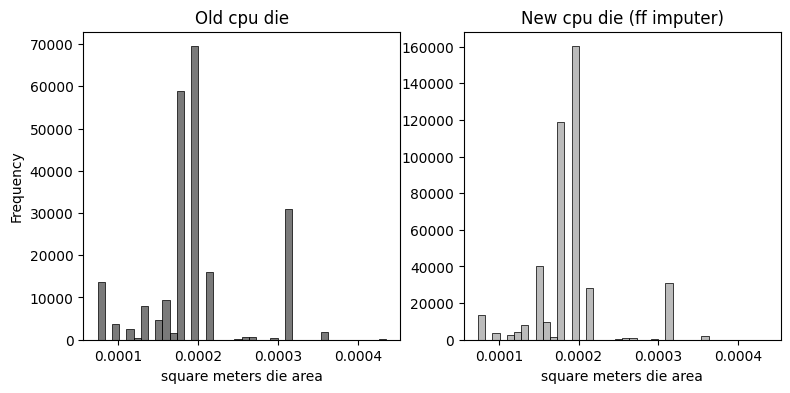

In [157]:
old_cpu_die = fps_df["cpu_die"]
new_cpu_die = fps_df_cp["cpu_die"]

X_LBL = "square meters die area"
Y_LBL = "Frequency"
old = "old die"
new = "new die (imputed)"
CLR_1 = "#222222"
CLR_2 = "#aaaaaa"

fig_act_prd, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

sns.histplot(old_cpu_die, label=old, color=CLR_1, alpha=0.6, bins=40, ax=ax1)
ax1.set_title("Old cpu die")
ax1.set_xlabel(X_LBL)
ax1.set_ylabel(Y_LBL)

sns.histplot(new_cpu_die, label=new, color=CLR_2, alpha=0.8, bins=40, ax=ax2)
ax2.set_title("New cpu die (ff imputer)")
ax2.set_xlabel(X_LBL)
ax2.set_ylabel("")

plt.show()

cpu_trnsstrs in real life must be greater than zero using ffill as did in cpu_die

In [158]:
#fps_df_clean["cpu_trnsstrs"] = value_replace(fps_df_clean, "cpu_trnsstrs", np.nan, value=0.0)
fps_df_cp["cpu_trnsstrs"] = propagate_valid(fps_df_cp, "cpu_trnsstrs", "cpu_prcss", True)

In [159]:
fps_df_cp["cpu_trnsstrs"].isnull().sum()

np.int64(0)

In [160]:
fps_df_cp["cpu_trnsstrs"].isna().sum()

np.int64(0)

In [161]:
fps_df_cp.cpu_trnsstrs.unique()

array([  731.,  1400.,  4800.,  9600.,  4950.,  1160.,  2600.,  1300.,
        1200.,  3800.,   382.,   504.,   300.,  1178.,   410.,   228.,
         105.,  1480.,   624.,  2270.,  1270.,   774.,   154., 19200.,
        1860.,   384.,   450.,  1170.])

In [162]:
fps_df_cp["cpu_trnsstrs"] = fps_df_cp["cpu_trnsstrs"].astype(int)

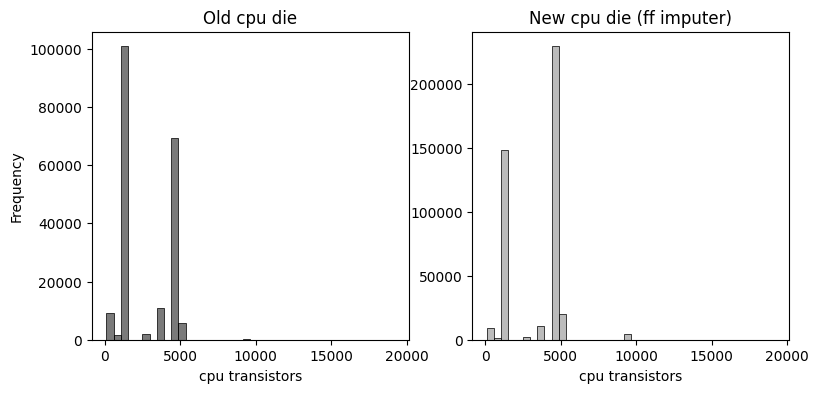

In [163]:
old_cpu_die = fps_df["cpu_trnsstrs"]
new_cpu_die = fps_df_cp["cpu_trnsstrs"]

X_LBL = "cpu transistors"
Y_LBL = "Frequency"
old = "old die"
new = "new die (imputed)"
CLR_1 = "#222222"
CLR_2 = "#aaaaaa"

fig_act_prd, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

sns.histplot(old_cpu_die, label=old, color=CLR_1, alpha=0.6, bins=40, ax=ax1)
ax1.set_title("Old cpu die")
ax1.set_xlabel(X_LBL)
ax1.set_ylabel(Y_LBL)

sns.histplot(new_cpu_die, label=new, color=CLR_2, alpha=0.8, bins=40, ax=ax2)
ax2.set_title("New cpu die (ff imputer)")
ax2.set_xlabel(X_LBL)
ax2.set_ylabel("")

plt.show()

In [164]:
fps_df_cp.duplicated().sum()

np.int64(424970)

In [165]:
fps_df_clean = fps_df_cp.copy()
fps_df_clean = fps_df_clean.drop_duplicates()
fps_df_clean.shape

(863, 14)

In [166]:
fps_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 863 entries, 0 to 422323
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cpu_cores       863 non-null    int64  
 1   cpu_threads     863 non-null    int64  
 2   cpu_clock       863 non-null    int64  
 3   cpu_L1          863 non-null    int64  
 4   cpu_L2          863 non-null    int64  
 5   cpu_L3          863 non-null    int64  
 6   cpu_die         863 non-null    float64
 7   cpu_frq         863 non-null    int64  
 8   cpu_multiplier  863 non-null    float64
 9   cpu_has_oc      863 non-null    int64  
 10  cpu_prcss       863 non-null    int64  
 11  cpu_tdp         863 non-null    int64  
 12  cpu_trnsstrs    863 non-null    int64  
 13  cpu_tclock      863 non-null    int64  
dtypes: float64(2), int64(12)
memory usage: 101.1 KB


In [167]:
fps_df_clean["cpu_has_oc"] = fps_df_clean["cpu_has_oc"].apply(lambda val: "Y" if val == 0 else "N")
fps_df_clean["cpu_has_oc"] = fps_df_clean["cpu_has_oc"].astype("object")
fps_df_clean.sample(4)

,cpu_cores,cpu_threads,cpu_clock,cpu_L1,cpu_L2,cpu_L3,cpu_die,cpu_frq,cpu_multiplier,cpu_has_oc,cpu_prcss,cpu_tdp,cpu_trnsstrs,cpu_tclock
29126,4,4,100,256,1024,6,0.000149,2800,28.0,Y,14,62,4800,3600
25533,4,8,100,384,2048,8,0.000192,3200,32.0,N,14,65,4800,3400
400813,10,20,100,320,2560,25,0.000177,3000,30.0,Y,14,140,3800,3500
2905,4,4,100,256,1024,6,0.000177,3400,34.0,Y,14,65,4800,3800


One thing I did not do was trying to put features in terms of the same unit if features share a unit between them e.g. express MHz in GHz for frequency this to maintain consistency during model training and aid in interpretability also if possible avoid Standardization

In [168]:
#express all frequencies in GHz
to_ghz = ["cpu_clock", "cpu_frq", "cpu_tclock"]
for col in to_ghz:
    fps_df_clean[col] = fps_df_clean[col].apply(lambda val: np.round(val/1000, 6)).astype(float)
fps_df_clean.sample(4)

,cpu_cores,cpu_threads,cpu_clock,cpu_L1,cpu_L2,cpu_L3,cpu_die,cpu_frq,cpu_multiplier,cpu_has_oc,cpu_prcss,cpu_tdp,cpu_trnsstrs,cpu_tclock
54969,2,4,0.1,128,512,3,0.000094,3.4,34.0,Y,22,55,2600,3.4
45809,16,32,0.1,1536,8192,32,0.000213,3.5,35.0,N,12,180,19200,4.4
201923,2,4,0.1,128,512,3,0.000246,3.5,35.0,Y,14,51,4800,3.5
60695,4,8,0.1,256,1024,8,0.000123,3.6,36.0,Y,14,65,4800,4.2


In [169]:
#express all MB in GB
to_gb = ["cpu_L1", "cpu_L2", "cpu_L3"]
for col in to_gb:
    fps_df_clean[col] = fps_df_clean[col].apply(lambda val: np.round(val/1_000, 6)).astype(float)
fps_df_clean.sample(4)

,cpu_cores,cpu_threads,cpu_clock,cpu_L1,cpu_L2,cpu_L3,cpu_die,cpu_frq,cpu_multiplier,cpu_has_oc,cpu_prcss,cpu_tdp,cpu_trnsstrs,cpu_tclock
56803,2,4,0.1,0.128,0.512,0.003,0.000150,2.0,20.0,Y,14,15,1400,2.0
143531,2,4,0.1,0.128,0.512,0.003,0.000123,3.9,39.0,Y,14,51,4800,3.9
8045,4,4,0.1,0.256,1.024,0.006,0.000123,3.5,35.0,N,14,95,1400,3.9
30930,4,8,0.1,0.256,1.024,0.006,0.000177,2.4,24.0,Y,22,47,1400,3.4


cpu_die should be expressed in mm², I am not sure if the unit of the available values is square meters or any other thing this difficults the conversion. But I can still try.

As die sizes shrink due to advancements in semiconductor technology, the power density—measured in watts per square millimeter—increases, making it more challenging to dissipate heat efficiently

In [170]:
#cpu die in mm² (square mm)
fps_df_clean["cpu_die"] = fps_df_clean["cpu_die"].apply(lambda val: np.round(val*1_000_000, 6)).astype(int)
fps_df_clean.sample(4)

,cpu_cores,cpu_threads,cpu_clock,cpu_L1,cpu_L2,cpu_L3,cpu_die,cpu_frq,cpu_multiplier,cpu_has_oc,cpu_prcss,cpu_tdp,cpu_trnsstrs,cpu_tclock
11299,4,8,0.1,0.256,1.024,0.008,160,3.5,35.0,N,22,77,1400,3.9
1319,4,4,0.1,0.256,1.024,0.006,133,3.2,32.0,Y,22,77,2600,3.6
198086,4,8,0.1,0.256,1.024,0.008,123,3.4,34.0,Y,14,65,1400,4.0
56911,3,3,0.2,0.384,1.536,0.000,169,2.7,13.5,Y,45,95,300,2.7


cpu_trnsstrs in modern cpus this value should be expressed in billions, in the dataset it seems to be expressed in millions. I am converting it to billions.

In [171]:
#cpu_trnsstrs in billions
fps_df_clean["cpu_trnsstrs"] = fps_df_clean["cpu_trnsstrs"].apply(lambda val: np.round(val/1_000, 6)).astype(float)
fps_df_clean.sample(4)

,cpu_cores,cpu_threads,cpu_clock,cpu_L1,cpu_L2,cpu_L3,cpu_die,cpu_frq,cpu_multiplier,cpu_has_oc,cpu_prcss,cpu_tdp,cpu_trnsstrs,cpu_tclock
44004,2,4,0.1,0.128,0.512,0.003,177,3.5,35.0,Y,14,51,1.400,3.5
231625,18,36,0.1,1.152,18.432,0.024,210,3.0,30.0,N,14,165,4.950,4.5
30090,2,2,0.1,0.128,0.512,0.003,131,2.9,29.0,Y,32,65,0.504,2.9
44332,4,8,0.1,0.512,2.048,0.004,210,2.1,21.0,Y,12,15,4.950,3.7


In [172]:
def get_numeric_features(df):
    num_ftrs = list(df.select_dtypes(include=["int64", "float64"]).columns)
    return num_ftrs

Start simple using all features

In [173]:
fps_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 863 entries, 0 to 422323
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cpu_cores       863 non-null    int64  
 1   cpu_threads     863 non-null    int64  
 2   cpu_clock       863 non-null    float64
 3   cpu_L1          863 non-null    float64
 4   cpu_L2          863 non-null    float64
 5   cpu_L3          863 non-null    float64
 6   cpu_die         863 non-null    int64  
 7   cpu_frq         863 non-null    float64
 8   cpu_multiplier  863 non-null    float64
 9   cpu_has_oc      863 non-null    object 
 10  cpu_prcss       863 non-null    int64  
 11  cpu_tdp         863 non-null    int64  
 12  cpu_trnsstrs    863 non-null    float64
 13  cpu_tclock      863 non-null    float64
dtypes: float64(8), int64(5), object(1)
memory usage: 101.1+ KB


Split data

In [174]:
train, test_vldtn = train_test_split(fps_df_clean, test_size=0.4, random_state=42)
vldtn, test = train_test_split(test_vldtn, test_size=0.5, random_state=42)
print(len(train))
print(len(test_vldtn))
print(len(vldtn))
print(len(test))

517
346
173
173


The change in the split sizes from the previous zero fill and this imputation is due to the removal of duplicates previously done to the imputation in the zero fill and the duplicate removal after the imputation in this case

In [175]:
train = train.reset_index(drop=True)
vldtn = vldtn.reset_index(drop=True)
test = test.reset_index(drop=True)

y_train = train.cpu_tclock.values
y_vldtn = vldtn.cpu_tclock.values
y_test = test.cpu_tclock.values

target = "cpu_tclock"
del train[target]
del vldtn[target]
del test[target]

Train split Feature scaling

In [176]:
def get_numeric_categoric_features(df):
    num_ftrs = list(df.select_dtypes(include=["int64", "float64"]).columns)
    ctgrcl_ftrs = list(df.select_dtypes(include=["object"]).columns)
    return num_ftrs, ctgrcl_ftrs

In [177]:
def vectorize_features(df):
    dct_vctrzr = DictVectorizer(sparse=True)

    orient = "records"
    df_dct = df.to_dict(orient=orient)
    X_vctrzd = dct_vctrzr.fit_transform(df_dct)

    return dct_vctrzr, X_vctrzd

In [178]:
dct_vctrzr, X_train = vectorize_features(train)

Lets do like in the homework

In [179]:
dt_reg = DecisionTreeRegressor(max_depth=1, random_state=42)
dt_reg.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [180]:
print(export_text(
        dt_reg, 
        feature_names=list(dct_vctrzr.get_feature_names_out())
    )
)

|--- cpu_L3 <= 0.01
|   |--- value: [3.01]
|--- cpu_L3 >  0.01
|   |--- value: [4.15]



Lets jump to the RandomForestRegressor

In [181]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [182]:
dct_vctrzr_vldtn, X_vldtn = vectorize_features(vldtn)

In [183]:
jobs = -1
rmse_scores = {}
depths = [7, 10, 15, 20]
estimators = np.linspace(100, 200, 11, dtype=int)
splits = [2, 3, 5]
leafs = [2, 3, 5]

for depth in depths:
    for estimator in estimators:
        for split in splits:
            for leaf in leafs:
                rnd_frst_reg = RandomForestRegressor(
                    n_estimators=estimator,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    min_samples_split=split,
                    random_state=42, 
                    n_jobs=jobs
                )
                rnd_frst_reg.fit(X_train, y_train)
                y_prdct = rnd_frst_reg.predict(X_vldtn)
                rmse_scores[str(depth)+"_"+str(estimator)+"_"+str(leaf)+"_"+str(split)] = np.round(rmse(y_vldtn, y_prdct), 3)

In [184]:
best_depth = min(rmse_scores, key=rmse_scores.get)
print(f"max_depth and estimator: {best_depth} lead to best RMSE score: {rmse_scores.get(best_depth)}")

max_depth and estimator: 10_120_2_2 lead to best RMSE score: 0.127


In [185]:
jobs = -1
rmse_score = {}
depth = 10
estimator = 120
leaf=2
split=2

rnd_frst_reg = RandomForestRegressor(
    n_estimators=estimator,
    max_depth=depth,
    min_samples_leaf=leaf,
    min_samples_split=split,
    random_state=42,
    n_jobs=jobs
)

rnd_frst_reg.fit(X_train, y_train)
y_prdct = rnd_frst_reg.predict(X_vldtn)
rmse_score[str(depth)+"_"+str(estimator)+"_"+str(leaf)+"_"+str(split)] = np.round(rmse(y_vldtn, y_prdct), 3)

In [186]:
rmse_score

{'10_120_2_2': np.float64(0.127)}

In [187]:
names = dct_vctrzr.get_feature_names_out()
importances = rnd_frst_reg.feature_importances_

In [188]:
importance_df = pd.DataFrame({"feature": names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False)
importance_df

,feature,importance
2,cpu_L3,0.580919
6,cpu_frq,0.200807
0,cpu_L1,0.078731
9,cpu_multiplier,0.064148
4,cpu_cores,0.021054
1,cpu_L2,0.012001
11,cpu_tdp,0.010847
10,cpu_prcss,0.007167
12,cpu_threads,0.006020
5,cpu_die,0.005971


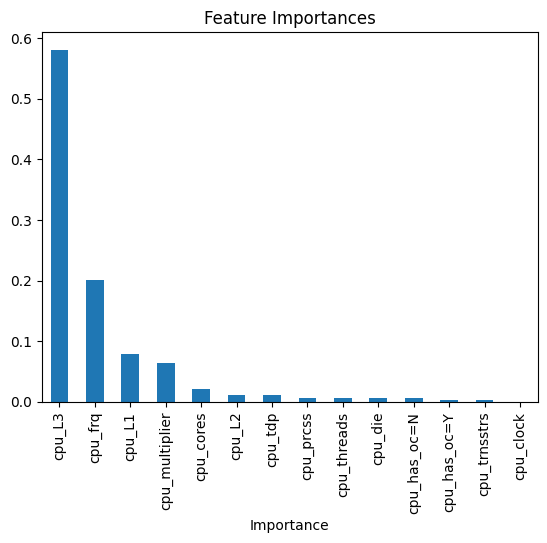

In [189]:
importance_df.set_index("feature")["importance"].plot.bar()
plt.xlabel("Importance")
plt.title("Feature Importances")
plt.show()

cpu_L3/L2/L1 are considered as important features, from a theoretical perspective they do not exactly contribute to the cpu ability to achieve higher fequencies, in the other hand they can contribute to cpu performance in terms of fetching data. I wonder what would happen if I remove them from the training process

In [190]:
selected_features = importance_df["feature"].to_list()
selected_features.remove("cpu_L3")
selected_features.remove("cpu_L2")
selected_features.remove("cpu_L1")
selected_features.remove("cpu_has_oc=N")
selected_features.remove("cpu_has_oc=Y")

selected_features.append("cpu_has_oc")

selected_features

['cpu_frq',
 'cpu_multiplier',
 'cpu_cores',
 'cpu_tdp',
 'cpu_prcss',
 'cpu_threads',
 'cpu_die',
 'cpu_trnsstrs',
 'cpu_clock',
 'cpu_has_oc']

In [191]:
dct_vctrzr, X_train = vectorize_features(train[selected_features])

In [192]:
dct_vctrzr_vldtn, X_vldtn = vectorize_features(vldtn[selected_features])

In [193]:
jobs = -1
rmse_scores = {}
depths = [7, 10, 15, 20]
estimators = np.linspace(100, 200, 11, dtype=int)
splits = [2, 3, 5]
leafs = [2, 3, 5]

for depth in depths:
    for estimator in estimators:
        for split in splits:
            for leaf in leafs:
                rnd_frst_reg = RandomForestRegressor(
                    n_estimators=estimator,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    min_samples_split=split,
                    random_state=42, 
                    n_jobs=jobs
                )
                rnd_frst_reg.fit(X_train, y_train)
                y_prdct = rnd_frst_reg.predict(X_vldtn)
                rmse_scores[str((depth, estimator, split, leaf))] = np.round(rmse(y_vldtn, y_prdct), 3)

In [194]:
best_depth = min(rmse_scores, key=rmse_scores.get)
print(f"max_depth and estimator: {best_depth} lead to best RMSE score: {rmse_scores.get(best_depth)}")

max_depth and estimator: (15, np.int64(100), 2, 2) lead to best RMSE score: 0.139


In [195]:
jobs = -1
rmse_score = {}
depth = 15
estimator = 100
leaf=2
split=2

rnd_frst_reg = RandomForestRegressor(
    n_estimators=estimator,
    max_depth=depth,
    min_samples_leaf=leaf,
    min_samples_split=split,
    random_state=42,
    n_jobs=jobs
)

rnd_frst_reg.fit(X_train, y_train)
y_prdct = rnd_frst_reg.predict(X_vldtn)
rmse_score[str(depth)+"_"+str(estimator)+"_"+str(leaf)+"_"+str(split)] = np.round(rmse(y_vldtn, y_prdct), 3)

In [196]:
rmse_score

{'15_100_2_2': np.float64(0.139)}

In [197]:
names = dct_vctrzr.get_feature_names_out()
importances = rnd_frst_reg.feature_importances_

In [198]:
importance_df = pd.DataFrame({"feature": names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False)
importance_df

,feature,importance
1,cpu_cores,0.284283
9,cpu_threads,0.280024
3,cpu_frq,0.267608
6,cpu_multiplier,0.081397
8,cpu_tdp,0.024398
4,cpu_has_oc=N,0.020098
7,cpu_prcss,0.015732
2,cpu_die,0.010414
5,cpu_has_oc=Y,0.008501
10,cpu_trnsstrs,0.007084


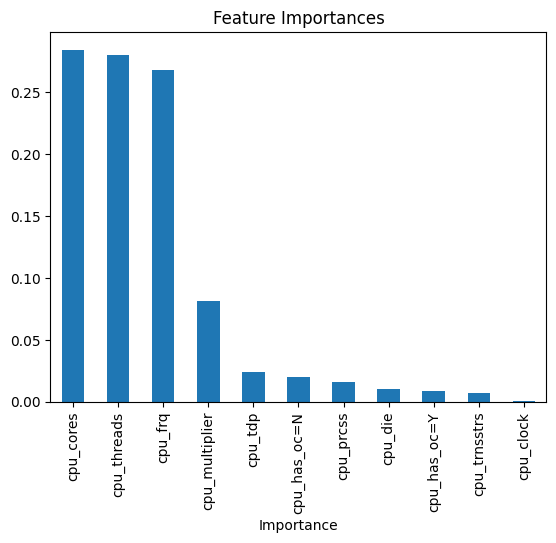

In [199]:
importance_df.set_index("feature")["importance"].plot.bar()
plt.xlabel("Importance")
plt.title("Feature Importances")
plt.show()

As expected rmse stayed nearly the same this is a good indicator now cpu_cores, cpu_frq and cpu_threads are most important features

Now  I can start removing less important features just to get a simpler model

In [200]:
selected_features = importance_df["feature"].to_list()
selected_features.remove("cpu_clock")
selected_features.remove("cpu_has_oc=N")
selected_features.remove("cpu_has_oc=Y")

selected_features.append("cpu_has_oc")

selected_features

['cpu_cores',
 'cpu_threads',
 'cpu_frq',
 'cpu_multiplier',
 'cpu_tdp',
 'cpu_prcss',
 'cpu_die',
 'cpu_trnsstrs',
 'cpu_has_oc']

In [201]:
dct_vctrzr, X_train = vectorize_features(train[selected_features])

In [202]:
dct_vctrzr, X_vldtn = vectorize_features(vldtn[selected_features])

In [203]:
jobs = -1
rmse_scores = {}
depths = [7, 10, 15, 20]
estimators = np.linspace(100, 200, 11, dtype=int)
splits = [2, 3, 5]
leafs = [2, 3, 5]

for depth in depths:
    for estimator in estimators:
        for split in splits:
            for leaf in leafs:
                rnd_frst_reg = RandomForestRegressor(
                    n_estimators=estimator,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    min_samples_split=split,
                    random_state=42, 
                    n_jobs=jobs
                )
                rnd_frst_reg.fit(X_train, y_train)
                y_prdct = rnd_frst_reg.predict(X_vldtn)
                rmse_scores[str((depth, estimator, split, leaf))] = np.round(rmse(y_vldtn, y_prdct), 3)

In [204]:
best_depth = min(rmse_scores, key=rmse_scores.get)
print(f"max_depth and estimator: {best_depth} lead to best RMSE score: {rmse_scores.get(best_depth)}")

max_depth and estimator: (10, np.int64(100), 2, 2) lead to best RMSE score: 0.14


In [205]:
jobs = -1
rmse_score = {}
depth = 10
estimator = 100
leaf=2
split=2

rnd_frst_reg = RandomForestRegressor(
    n_estimators=estimator,
    max_depth=depth,
    min_samples_leaf=leaf,
    min_samples_split=split,
    random_state=42,
    n_jobs=jobs
)

rnd_frst_reg.fit(X_train, y_train)
y_prdct = rnd_frst_reg.predict(X_vldtn)
rmse_score[str(depth)+"_"+str(estimator)+"_"+str(leaf)+"_"+str(split)] = np.round(rmse(y_vldtn, y_prdct), 3)

In [206]:
rmse_score

{'10_100_2_2': np.float64(0.14)}

In [207]:
names = dct_vctrzr.get_feature_names_out()
importances = rnd_frst_reg.feature_importances_

In [208]:
importance_df = pd.DataFrame({"feature": names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False)
importance_df

,feature,importance
0,cpu_cores,0.284511
8,cpu_threads,0.280121
2,cpu_frq,0.267452
5,cpu_multiplier,0.081839
7,cpu_tdp,0.024133
3,cpu_has_oc=N,0.018447
6,cpu_prcss,0.015387
1,cpu_die,0.010464
4,cpu_has_oc=Y,0.010163
9,cpu_trnsstrs,0.007484


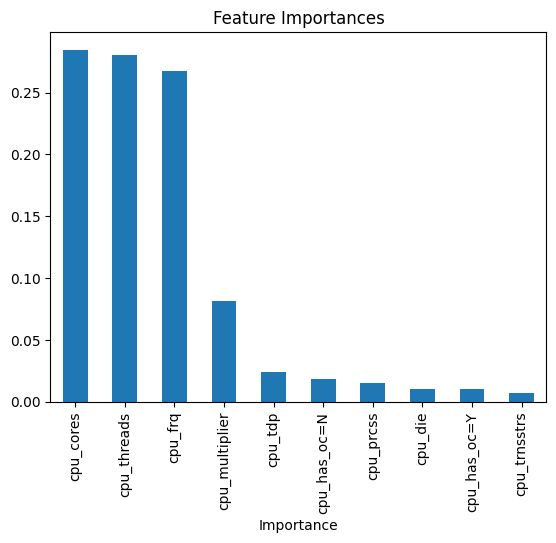

In [209]:
importance_df.set_index("feature")["importance"].plot.bar()
plt.xlabel("Importance")
plt.title("Feature Importances")
plt.show()

In [210]:
selected_features = importance_df["feature"].to_list()
selected_features.remove("cpu_trnsstrs")
selected_features.remove("cpu_has_oc=N")
selected_features.remove("cpu_has_oc=Y")

selected_features.append("cpu_has_oc")

selected_features

['cpu_cores',
 'cpu_threads',
 'cpu_frq',
 'cpu_multiplier',
 'cpu_tdp',
 'cpu_prcss',
 'cpu_die',
 'cpu_has_oc']

In [211]:
dct_vctrzr, X_train = vectorize_features(train[selected_features])

In [212]:
dct_vctrzr, X_vldtn = vectorize_features(vldtn[selected_features])

In [213]:
jobs = -1
rmse_scores = {}
depths = [7, 10, 15, 20]
estimators = np.linspace(100, 200, 11, dtype=int)
splits = [2, 3, 5]
leafs = [2, 3, 5]

for depth in depths:
    for estimator in estimators:
        for split in splits:
            for leaf in leafs:
                rnd_frst_reg = RandomForestRegressor(
                    n_estimators=estimator,
                    max_depth=depth,
                    min_samples_leaf=leaf,
                    min_samples_split=split,
                    random_state=42, 
                    n_jobs=jobs
                )
                rnd_frst_reg.fit(X_train, y_train)
                y_prdct = rnd_frst_reg.predict(X_vldtn)
                rmse_scores[str((depth, estimator, split, leaf))] = np.round(rmse(y_vldtn, y_prdct), 3)

In [214]:
best_depth = min(rmse_scores, key=rmse_scores.get)
print(f"max_depth and estimator: {best_depth} lead to best RMSE score: {rmse_scores.get(best_depth)}")

max_depth and estimator: (10, np.int64(100), 2, 2) lead to best RMSE score: 0.136


In [215]:
jobs = -1
rmse_score = {}
depth = 10
estimator = 100
leaf=2
split=2

rnd_frst_reg = RandomForestRegressor(
    n_estimators=estimator,
    max_depth=depth,
    min_samples_leaf=leaf,
    min_samples_split=split,
    random_state=42,
    n_jobs=jobs
)

rnd_frst_reg.fit(X_train, y_train)
y_prdct = rnd_frst_reg.predict(X_vldtn)
rmse_score[str(depth)+"_"+str(estimator)+"_"+str(leaf)+"_"+str(split)] = np.round(rmse(y_vldtn, y_prdct), 3)

In [216]:
rmse_score

{'10_100_2_2': np.float64(0.136)}

In [217]:
names = dct_vctrzr.get_feature_names_out()
importances = rnd_frst_reg.feature_importances_

In [218]:
importance_df = pd.DataFrame({"feature": names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False)
importance_df

,feature,importance
0,cpu_cores,0.284573
8,cpu_threads,0.280462
2,cpu_frq,0.268772
5,cpu_multiplier,0.082950
7,cpu_tdp,0.024962
3,cpu_has_oc=N,0.018256
6,cpu_prcss,0.018083
1,cpu_die,0.011285
4,cpu_has_oc=Y,0.010658


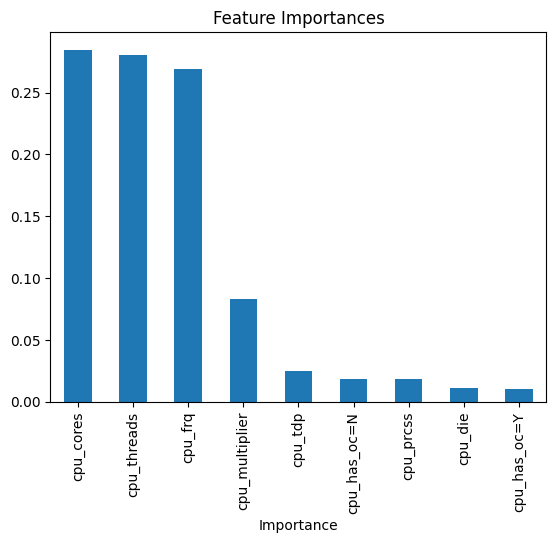

In [219]:
importance_df.set_index("feature")["importance"].plot.bar()
plt.xlabel("Importance")
plt.title("Feature Importances")
plt.show()

In [220]:
rmse_score

{'10_100_2_2': np.float64(0.136)}

In [221]:
print(y_vldtn[:5])
print(np.round(y_prdct[:5],3))

[3.7 4.5 4.1 4.  4.4]
[3.865 4.379 4.266 4.003 4.408]


In [222]:
print(y_vldtn.std())
print(y_prdct.std())

0.6304913200202967
0.6225038755112308


Using all features 14 yield a rmse of 0.127

Use depth 10, estimators 120, min_samples_split 2, min_samples_leaf 2

So the final model parameters yield a rmse of 0.136

Use 8 from the 14 features

Use depth 10, estimators 100, min_samples_split 2, min_samples_leaf 2

The RandomForestRegressor performed much better than the LinearModel this is expected as outliers and other aspects of Linear Models are not considered by trees as criteria to make decisions is different

Pipeline

In [223]:
selected_features = importance_df["feature"].to_list()
selected_features.remove("cpu_has_oc=N")
selected_features.remove("cpu_has_oc=Y")

selected_features.append("cpu_has_oc")

selected_features

['cpu_cores',
 'cpu_threads',
 'cpu_frq',
 'cpu_multiplier',
 'cpu_tdp',
 'cpu_prcss',
 'cpu_die',
 'cpu_has_oc']

In [224]:
cpu_tf_pl = make_pipeline(
    DictVectorizer(),
    RandomForestRegressor(
        max_depth=10,
        n_estimators=100,
        min_samples_split=2,
        min_samples_leaf=2,
        random_state=42
    )
)

In [225]:
X_train_dct = train[selected_features].to_dict(orient='records')
cpu_tf_pl.fit(X_train_dct, y_train)

,steps,"[('dictvectorizer', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,dtype,<class 'numpy.float64'>
,separator,'='
,sparse,True
,sort,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,10


In [226]:
def save_pipeline(pipeline, filename):
    with open(filename, "wb") as outfile:
        pickle.dump(pipeline, outfile)
    print(f"Saved pipeline check cwd for: {filename}")

In [227]:
save_pipeline(cpu_tf_pl, "cpu_tf_rfpl_v1.bin")

Saved pipeline check cwd for: cpu_tf_rfpl_v1.bin


In [228]:
X_vldtn = vldtn[selected_features].to_dict(orient='records')
y_prdct_vldtn = cpu_tf_pl.predict(X_vldtn)

In [229]:
rmse_vldtn = rmse(y_vldtn, y_prdct_vldtn)
print(rmse_vldtn)

0.13620120084617895


In [230]:
r2_score(y_true=y_vldtn, y_pred=y_prdct_vldtn)

0.9533336698462213